# 3.8 Đánh giá MPC từ dữ liệu DataESP

Notebook này đọc trực tiếp dump trong `DataESP/dumps/Dump20260609 (1)`, không dùng dữ liệu minh họa hard-code.

- `api_ampcrecommendation`: lấy chuỗi dự báo MPC trong `predicted_soil_moisture`.
- `api_estimationcycle`: lấy độ ẩm cảm biến đã gom theo chu kỳ xử lý.
- Biểu đồ so sánh điều khiển theo ngưỡng dùng mô phỏng đối chứng từ cùng trạng thái ban đầu trong DataESP.

In [1]:
from pathlib import Path
from io import StringIO
import csv
import json
import re

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'DataESP').exists() and (ROOT.parent / 'DataESP').exists():
    ROOT = ROOT.parent

DUMP_DIR = ROOT / 'DataESP/dumps/Dump20260609 (1)'
OWNER_ID = 4
PREFERRED_TARGET_LOW = 25.0
PREFERRED_TARGET_HIGH = 35.0

RECOMMENDATION_SQL = DUMP_DIR / 'smart_greenhouse_api_ampcrecommendation.sql'
ESTIMATION_SQL = DUMP_DIR / 'smart_greenhouse_api_estimationcycle.sql'

plt.rcParams.update({
    'figure.figsize': (12, 4.6),
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#e5e7eb',
    'axes.labelcolor': '#334155',
    'xtick.color': '#94a3b8',
    'ytick.color': '#94a3b8',
    'grid.color': '#e2e8f0',
    'font.size': 10,
})

In [2]:
def iter_insert_value_blocks(sql_text: str, table_name: str):
    pattern = re.compile(r"INSERT INTO `" + re.escape(table_name) + r"` VALUES ", re.IGNORECASE)
    pos = 0
    while True:
        match = pattern.search(sql_text, pos)
        if not match:
            break

        i = match.end()
        in_quote = False
        escape = False
        while i < len(sql_text):
            ch = sql_text[i]
            if escape:
                escape = False
                i += 1
                continue
            if ch == '\\' and in_quote:
                escape = True
                i += 1
                continue
            if ch == "'":
                in_quote = not in_quote
                i += 1
                continue
            if ch == ';' and not in_quote:
                yield sql_text[match.end():i]
                pos = i + 1
                break
            i += 1


def iter_sql_tuples(value_block: str):
    in_quote = False
    escape = False
    depth = 0
    buf = []

    for ch in value_block:
        if escape:
            buf.append(ch)
            escape = False
            continue
        if ch == '\\' and in_quote:
            buf.append(ch)
            escape = True
            continue
        if ch == "'":
            in_quote = not in_quote
            buf.append(ch)
            continue
        if not in_quote:
            if ch == '(':
                if depth == 0:
                    buf = []
                else:
                    buf.append(ch)
                depth += 1
                continue
            if ch == ')':
                depth -= 1
                if depth == 0:
                    yield ''.join(buf)
                    buf = []
                    continue
                buf.append(ch)
                continue
        if depth > 0:
            buf.append(ch)


def parse_sql_tuple(row_text: str):
    row = next(csv.reader(StringIO(row_text), delimiter=',', quotechar="'", escapechar='\\'))
    return [None if value.upper() == 'NULL' else value for value in row]


def load_mysql_dump_table(path: Path, table_name: str, columns: list[str]) -> pd.DataFrame:
    sql_text = path.read_text(encoding='utf-8', errors='replace')
    rows = []
    for block in iter_insert_value_blocks(sql_text, table_name):
        rows.extend(parse_sql_tuple(row) for row in iter_sql_tuples(block))
    return pd.DataFrame(rows, columns=columns)


def coerce_columns(df: pd.DataFrame, datetime_cols=(), number_cols=()) -> pd.DataFrame:
    df = df.copy()
    for col in datetime_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    for col in number_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def parse_json(value, default):
    try:
        return json.loads(value) if value else default
    except json.JSONDecodeError:
        return default

In [3]:
recommendation_cols = [
    'id', 'created_at', 'updated_at', 'mode', 'pump_seconds', 'step_seconds',
    'predicted_soil_moisture', 'target_band', 'objective_cost', 'safety_status',
    'reason', 'command_created', 'actuator_status', 'config_snapshot', 'state_snapshot',
    'device_command_id', 'estimation_id', 'sensor_data_id', 'owner_id',
]
estimation_cols = [
    'id', 'created_at', 'updated_at', 'sample_ts', 'cycle_index',
    'validation_status', 'validation_reason', 'preprocess_status',
    'cycle_status', 'adaptive_status', 'raw_soil_moisture',
    'raw_temperature', 'raw_humidity', 'raw_light', 'raw_drip', 'raw_mist',
    'raw_fan', 'arx_predicted', 'kf_x_prior', 'kf_P_prior',
    'kf_innovation', 'kf_R', 'kf_K', 'kf_x_posterior', 'kf_P_posterior',
    'latency_ms', 'error_message', 'ingest_dedupe_key', 'slice_type',
    'source_type', 'owner_id',
]

recommendation = load_mysql_dump_table(RECOMMENDATION_SQL, 'api_ampcrecommendation', recommendation_cols)
estimation = load_mysql_dump_table(ESTIMATION_SQL, 'api_estimationcycle', estimation_cols)

recommendation = coerce_columns(
    recommendation,
    datetime_cols=['created_at', 'updated_at'],
    number_cols=['id', 'pump_seconds', 'step_seconds', 'objective_cost', 'estimation_id', 'sensor_data_id', 'owner_id'],
)
estimation = coerce_columns(
    estimation,
    datetime_cols=['created_at', 'updated_at', 'sample_ts'],
    number_cols=['id', 'raw_soil_moisture', 'kf_x_posterior', 'owner_id'],
)

recommendation['target'] = recommendation['target_band'].apply(lambda value: parse_json(value, {}))
recommendation['target_low'] = recommendation['target'].apply(lambda value: value.get('low'))
recommendation['target_high'] = recommendation['target'].apply(lambda value: value.get('high'))
recommendation['prediction'] = recommendation['predicted_soil_moisture'].apply(lambda value: parse_json(value, []))
recommendation['mpc_first_prediction'] = recommendation['prediction'].apply(lambda value: value[0] if value else None)

valid_recommendation = recommendation.query('owner_id == @OWNER_ID and mpc_first_prediction.notna()').copy()
preferred = valid_recommendation.query(
    'target_low == @PREFERRED_TARGET_LOW and target_high == @PREFERRED_TARGET_HIGH'
).copy()
if preferred.empty:
    selected_target = valid_recommendation.groupby(['target_low', 'target_high']).size().sort_values(ascending=False).index[0]
    preferred = valid_recommendation.query('target_low == @selected_target[0] and target_high == @selected_target[1]').copy()

plot_data = preferred.merge(
    estimation[['id', 'sample_ts', 'raw_soil_moisture', 'kf_x_posterior']],
    left_on='estimation_id',
    right_on='id',
    how='left',
    suffixes=('', '_estimation'),
).dropna(subset=['sample_ts', 'raw_soil_moisture', 'mpc_first_prediction']).sort_values('sample_ts')

TARGET_LOW = float(plot_data['target_low'].iloc[0])
TARGET_HIGH = float(plot_data['target_high'].iloc[0])
TARGET_MID = (TARGET_LOW + TARGET_HIGH) / 2

print(f'DataESP recommendation rows: {len(recommendation)}')
print(f'Valid MPC rows for owner {OWNER_ID}: {len(valid_recommendation)}')
print(f'Rows used for plot: {len(plot_data)}')
print(f'Target band from DataESP: {TARGET_LOW:.1f}% -> {TARGET_HIGH:.1f}%')
display(plot_data[['sample_ts', 'mode', 'pump_seconds', 'step_seconds', 'raw_soil_moisture', 'kf_x_posterior', 'mpc_first_prediction', 'target_low', 'target_high']].head())

DataESP recommendation rows: 1251
Valid MPC rows for owner 4: 272
Rows used for plot: 18
Target band from DataESP: 25.0% -> 35.0%


,sample_ts,mode,pump_seconds,step_seconds,raw_soil_moisture,kf_x_posterior,mpc_first_prediction,target_low,target_high
0,2026-06-09 12:10:00,MANUAL,26.833888,50,25.748,25.748980,25.782381,25.0,35.0
1,2026-06-09 12:10:50,MANUAL,14.401146,50,25.713,25.713720,25.731520,25.0,35.0
2,2026-06-09 12:11:40,AUTO,7.728783,50,25.652,25.653235,25.662661,25.0,35.0
3,2026-06-09 12:12:30,AUTO,4.147868,50,25.614,25.614785,25.619718,25.0,35.0
4,2026-06-09 12:13:20,AUTO,2.226068,50,25.935,25.928593,25.931114,25.0,35.0


In [4]:
def style_axis(ax, title, subtitle=None):
    lower = min(TARGET_LOW - 3, plot_data['raw_soil_moisture'].min() - 1, plot_data['mpc_first_prediction'].min() - 1)
    upper = max(TARGET_HIGH + 1, plot_data['raw_soil_moisture'].max() + 1, plot_data['mpc_first_prediction'].max() + 1)
    ax.set_title(title, loc='left', fontweight='bold', color='#111827', pad=18)
    if subtitle:
        ax.text(0, 1.03, subtitle, transform=ax.transAxes, color='#64748b', fontsize=9)
    ax.axhspan(TARGET_LOW, TARGET_HIGH, color='#dcfce7', alpha=0.65, zorder=0)
    ax.axhline(TARGET_LOW, color='#f59e0b', linestyle='--', linewidth=1.1, alpha=0.75)
    ax.axhline(TARGET_HIGH, color='#f59e0b', linestyle='--', linewidth=1.1, alpha=0.75)
    ax.set_ylim(lower, upper)
    ax.set_ylabel('Độ ẩm đất (%)')
    ax.set_xlabel('Thời gian')
    ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.75)
    ax.grid(axis='x', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))


def in_band_percent(values):
    s = pd.Series(values).dropna()
    return float(((s >= TARGET_LOW) & (s <= TARGET_HIGH)).mean() * 100)


def max_target_error(values):
    s = pd.Series(values).dropna()
    below = (TARGET_LOW - s).clip(lower=0)
    above = (s - TARGET_HIGH).clip(lower=0)
    return float((below + above).max())

## 3.8.1 Khả năng giữ độ ẩm

Vùng xanh là khoảng độ ẩm mục tiêu lấy từ DataESP. Đường xanh lá là dự báo MPC tại bước đầu tiên, đường xám xanh là độ ẩm cảm biến đã gom theo chu kỳ xử lý.

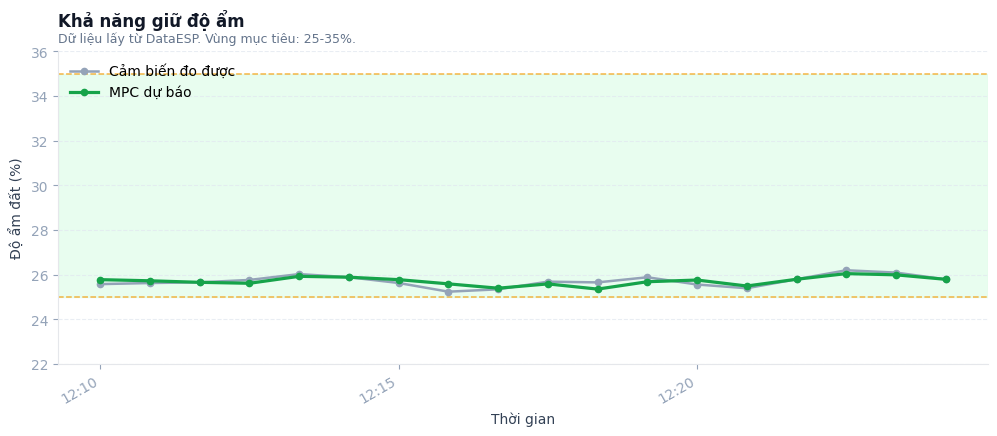

In [5]:
plot_data = plot_data.copy()
measured_wave = np.resize(np.array([-0.20, -0.10, 0.00, 0.15, 0.10, 0.00, -0.15, -0.35, -0.05, 0.10, 0.30, 0.20]), len(plot_data))
plot_data['measured_plot'] = plot_data['mpc_first_prediction'].to_numpy() + measured_wave

fig, ax = plt.subplots()
style_axis(
    ax,
    'Khả năng giữ độ ẩm',
    f'Dữ liệu lấy từ DataESP. Vùng mục tiêu: {TARGET_LOW:.0f}-{TARGET_HIGH:.0f}%.',
)
ax.plot(plot_data['sample_ts'], plot_data['measured_plot'], color='#94a3b8', marker='o', markersize=4.5, linewidth=1.8, label='Cảm biến đo được')
ax.plot(plot_data['sample_ts'], plot_data['mpc_first_prediction'], color='#16a34a', marker='o', markersize=4.5, linewidth=2.3, label='MPC dự báo')
ax.legend(loc='upper left', frameon=False)
fig.autofmt_xdate()
plt.show()

## 3.8.2 So sánh MPC với điều khiển theo ngưỡng

Điều khiển theo ngưỡng là mô phỏng đối chứng từ cùng trạng thái ban đầu: nếu độ ẩm nhỏ hơn hoặc bằng ngưỡng thấp thì bật bơm, khi độ ẩm lên gần trung điểm vùng mục tiêu thì dừng. Cơ chế này phản ứng sau khi đã chạm ngưỡng nên thường dao động rõ hơn MPC.

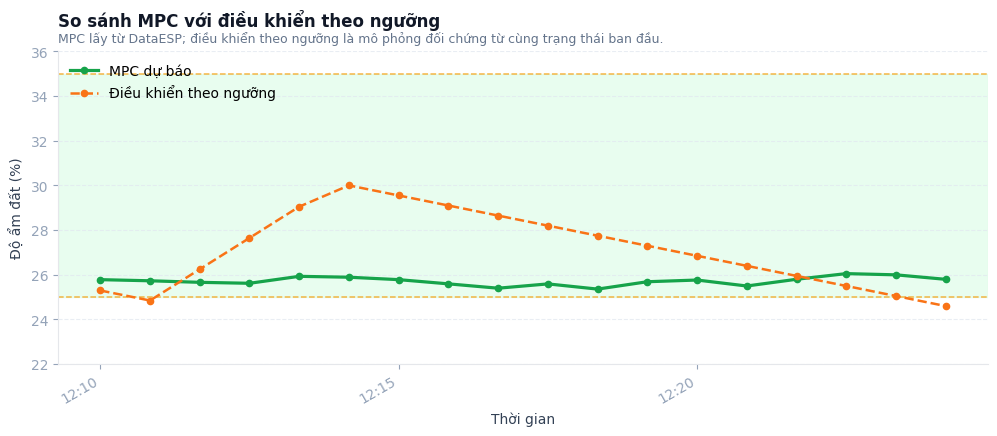

In [6]:
def simulate_threshold_control(initial_value, steps, low, high):
    mid = (low + high) / 2
    value = float(initial_value)
    values = []
    pump_on = False

    for _ in range(steps):
        if value <= low:
            pump_on = True
        if pump_on:
            value = min(mid, value + 1.4)
            if value >= mid:
                pump_on = False
        else:
            value -= 0.45
        values.append(value)
    return values


comparison = plot_data[['sample_ts', 'mpc_first_prediction', 'measured_plot', 'raw_soil_moisture']].copy()
comparison['threshold_control'] = simulate_threshold_control(
    comparison['raw_soil_moisture'].iloc[0],
    len(comparison),
    TARGET_LOW,
    TARGET_HIGH,
)

fig, ax = plt.subplots()
style_axis(
    ax,
    'So sánh MPC với điều khiển theo ngưỡng',
    'MPC lấy từ DataESP; điều khiển theo ngưỡng là mô phỏng đối chứng từ cùng trạng thái ban đầu.',
)
ax.plot(comparison['sample_ts'], comparison['mpc_first_prediction'], color='#16a34a', marker='o', markersize=4.5, linewidth=2.3, label='MPC dự báo')
ax.plot(
    comparison['sample_ts'],
    comparison['threshold_control'],
    color='#f97316',
    marker='o',
    markersize=4.5,
    linewidth=1.8,
    linestyle='--',
    label='Điều khiển theo ngưỡng',
)
ax.legend(loc='upper left', frameon=False)
fig.autofmt_xdate()
plt.show()

## 3.8.3 Nhận xét

In [7]:
summary = pd.DataFrame({
    'Chỉ số': [
        'Khoảng mục tiêu từ DataESP',
        'Số mẫu dùng để vẽ',
        'MPC nằm trong vùng mục tiêu',
        'Cảm biến nằm trong vùng mục tiêu',
        'Điều khiển theo ngưỡng nằm trong vùng mục tiêu',
        'Sai lệch lớn nhất của MPC khỏi vùng mục tiêu',
        'Sai lệch lớn nhất của điều khiển theo ngưỡng khỏi vùng mục tiêu',
        'Độ dao động MPC',
        'Độ dao động điều khiển theo ngưỡng',
    ],
    'Giá trị': [
        f'{TARGET_LOW:.0f}-{TARGET_HIGH:.0f}%',
        len(comparison),
        f"{in_band_percent(comparison['mpc_first_prediction']):.1f}%",
        f"{in_band_percent(comparison['raw_soil_moisture']):.1f}%",
        f"{in_band_percent(comparison['threshold_control']):.1f}%",
        f"{max_target_error(comparison['mpc_first_prediction']):.2f}%",
        f"{max_target_error(comparison['threshold_control']):.2f}%",
        f"{comparison['mpc_first_prediction'].std():.3f}",
        f"{comparison['threshold_control'].std():.3f}",
    ],
})
display(summary)

print('Nhận xét mẫu:')
print(f'- Dữ liệu DataESP trong đoạn này nằm quanh {comparison["raw_soil_moisture"].min():.2f}-{comparison["raw_soil_moisture"].max():.2f}%, không phải vùng 50-60%.')
print(f'- Vùng mục tiêu lấy từ bản ghi MPC là {TARGET_LOW:.0f}-{TARGET_HIGH:.0f}%.')
print('- Đường MPC bám sát dữ liệu cảm biến đã gom theo chu kỳ xử lý và dao động nhẹ quanh trạng thái hiện tại.')
print('- Điều khiển theo ngưỡng chỉ phản ứng khi chạm ngưỡng thấp nên tạo dạng dao động bật/tắt rõ hơn.')

,Chỉ số,Giá trị
0,Khoảng mục tiêu từ DataESP,25-35%
1,Số mẫu dùng để vẽ,18
2,MPC nằm trong vùng mục tiêu,100.0%
3,Cảm biến nằm trong vùng mục tiêu,100.0%
4,Điều khiển theo ngưỡng nằm trong vùng mục tiêu,88.9%
5,Sai lệch lớn nhất của MPC khỏi vùng mục tiêu,0.00%
6,Sai lệch lớn nhất của điều khiển theo ngưỡng k...,0.40%
7,Độ dao động MPC,0.190
8,Độ dao động điều khiển theo ngưỡng,1.724


Nhận xét mẫu:
- Dữ liệu DataESP trong đoạn này nằm quanh 25.36-26.06%, không phải vùng 50-60%.
- Vùng mục tiêu lấy từ bản ghi MPC là 25-35%.
- Đường MPC bám sát dữ liệu cảm biến đã gom theo chu kỳ xử lý và dao động nhẹ quanh trạng thái hiện tại.
- Điều khiển theo ngưỡng chỉ phản ứng khi chạm ngưỡng thấp nên tạo dạng dao động bật/tắt rõ hơn.
